In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'D:\SIC_P1_G16\dataset\housing_data_CDMX.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  object 
 1   places                      18234 non-null  object 
 2   lat-lon                     18234 non-null  object 
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  object 
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


In [4]:
df.head()

,property_type,places,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2
0,apartment,MiguelHidalgo,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190
1,house,Iztapalapa,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000
2,apartment,Tlalpan,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000
3,apartment,MiguelHidalgo,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148
4,apartment,MiguelHidalgo,"19.432657,-99.177444",4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069


# Duplicated and nulls handling

In [5]:
df.duplicated().sum()

np.int64(2953)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.isnull().sum()

property_type                 0
places                        0
lat-lon                       0
price                         0
currency                      0
price_aprox_local_currency    0
price_aprox_usd               0
surface_total_in_m2           0
surface_covered_in_m2         0
price_usd_per_m2              0
price_per_m2                  0
dtype: int64

# split lat-lon column to two column

In [8]:
df[['latitude', 'longitude']] = df['lat-lon'].str.split(',', expand=True)

df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

df.drop('lat-lon', axis=1, inplace=True)

Chack nulls for new columns

In [9]:
df.isnull().sum()

property_type                   0
places                          0
price                           0
currency                        0
price_aprox_local_currency      0
price_aprox_usd                 0
surface_total_in_m2             0
surface_covered_in_m2           0
price_usd_per_m2                0
price_per_m2                    0
latitude                      103
longitude                     103
dtype: int64

In [10]:
df[['latitude', 'longitude']] = df[['latitude', 'longitude']].fillna(df[['latitude', 'longitude']].mean())

In [11]:
df.head()

,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
0,apartment,MiguelHidalgo,5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190,23.634501,-102.552788
1,house,Iztapalapa,1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000,19.310330,-99.068557
2,apartment,Tlalpan,926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000,19.279771,-99.234597
3,apartment,MiguelHidalgo,6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148,23.634501,-102.552788
4,apartment,MiguelHidalgo,4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069,19.432657,-99.177444


# outliers handling

In [12]:
num_cols = df.select_dtypes(include=['number']).columns

print("Numerical columns:", num_cols)

df[num_cols].describe().round()

Numerical columns: Index(['price', 'price_aprox_local_currency', 'price_aprox_usd',
       'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2',
       'price_per_m2', 'latitude', 'longitude'],
      dtype='object')


,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,15281.0,15281.0,15281.0,15281.0,15281.0,15281.0,15281.0,15281.0,15281.0
mean,3751468.0,5481206.0,291422.0,4826.0,4799.0,1506.0,24289.0,19.0,-99.0
std,5874121.0,10277686.0,546438.0,532273.0,532271.0,2282.0,43594.0,1.0,0.0
min,7000.0,109031.0,5797.0,1.0,1.0,0.0,0.0,19.0,-103.0
25%,1029394.0,1090049.0,57955.0,70.0,70.0,659.0,11089.0,19.0,-99.0
50%,2000000.0,2298022.0,122180.0,100.0,100.0,1064.0,17714.0,19.0,-99.0
75%,4110000.0,4954768.0,263432.0,205.0,218.0,1896.0,31944.0,19.0,-99.0
max,233726700.0,336484065.0,17890000.0,65748000.0,65748000.0,175918.0,3338953.0,42.0,-90.0


In [13]:
df.shape

(15281, 12)

In [14]:
num_cols = [
    'price',
    'price_aprox_local_currency',
    'price_aprox_usd',
    'surface_total_in_m2',
    'surface_covered_in_m2',
    'price_usd_per_m2',
    'price_per_m2'
]

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    df[col] = df[col].clip(lower=lower)# upper=upper)

    print(f"{col}: {outliers} outliers clipped")

price: 1392 outliers clipped
price_aprox_local_currency: 1944 outliers clipped
price_aprox_usd: 1944 outliers clipped
surface_total_in_m2: 1407 outliers clipped
surface_covered_in_m2: 1291 outliers clipped
price_usd_per_m2: 809 outliers clipped
price_per_m2: 506 outliers clipped


In [15]:
df=df[df["surface_total_in_m2"]<=1000]
df=df[df['price_aprox_usd'] <= 1000000]


In [16]:
df.shape

(14193, 12)

In [17]:
df[num_cols] = df[num_cols].round(1)

In [18]:
df.describe().round()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0
mean,3149528.0,3432580.0,182502.0,144.0,147.0,1349.0,23801.0,19.0,-99.0
std,3270001.0,3654735.0,194313.0,130.0,133.0,1622.0,22721.0,1.0,0.0
min,7000.0,109031.0,5797.0,1.0,1.0,15.0,20.0,19.0,-103.0
25%,990000.0,1037198.0,55145.0,67.0,68.0,649.0,11683.0,19.0,-99.0
50%,1986559.0,2081003.0,110642.0,90.0,90.0,1010.0,18092.0,19.0,-99.0
75%,3960000.0,4261101.0,226552.0,176.0,180.0,1756.0,31803.0,19.0,-99.0
max,18970000.0,18808500.0,1000000.0,1000.0,1900.0,140000.0,930000.0,42.0,-90.0


In [19]:
(df[num_cols] < 10).sum()

price                         0
price_aprox_local_currency    0
price_aprox_usd               0
surface_total_in_m2           6
surface_covered_in_m2         9
price_usd_per_m2              0
price_per_m2                  0
dtype: int64

In [20]:
for col in num_cols:
    df[col] = df[col].clip(lower=10)

In [21]:
df.describe().round()

,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
count,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0,14193.0
mean,3149528.0,3432580.0,182502.0,144.0,147.0,1349.0,23801.0,19.0,-99.0
std,3270001.0,3654735.0,194313.0,130.0,133.0,1622.0,22721.0,1.0,0.0
min,7000.0,109031.0,5797.0,10.0,10.0,15.0,20.0,19.0,-103.0
25%,990000.0,1037198.0,55145.0,67.0,68.0,649.0,11683.0,19.0,-99.0
50%,1986559.0,2081003.0,110642.0,90.0,90.0,1010.0,18092.0,19.0,-99.0
75%,3960000.0,4261101.0,226552.0,176.0,180.0,1756.0,31803.0,19.0,-99.0
max,18970000.0,18808500.0,1000000.0,1000.0,1900.0,140000.0,930000.0,42.0,-90.0


In [22]:
df.head()

,property_type,places,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,latitude,longitude
0,apartment,MiguelHidalgo,5500000.0,MXN,5450245.5,289775.7,54.0,54.0,5366.2,101851.9,23.634501,-102.552788
1,house,Iztapalapa,1512000.0,MXN,1498322.0,79662.0,80.0,80.0,995.8,18900.0,19.310330,-99.068557
2,apartment,Tlalpan,926667.0,MXN,918284.0,48822.8,100.0,100.0,488.2,9266.7,19.279771,-99.234597
3,apartment,MiguelHidalgo,6410000.0,MXN,6352013.4,337720.4,135.0,135.0,2501.6,47481.5,23.634501,-102.552788
4,apartment,MiguelHidalgo,4416000.0,MXN,4376051.6,232663.5,87.0,87.0,2674.3,50758.6,19.432657,-99.177444


# **Exploratory Data Analysis (EDA)**

 **1-Descriptive Statistics Overview**

In [23]:
df[num_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
price,14193.0,3149527.81,3270000.65,7000.0,990000.0,1986559.0,3960000.0,18970000.0
price_aprox_local_currency,14193.0,3432580.40,3654734.90,109030.6,1037198.5,2081002.7,4261101.0,18808500.0
price_aprox_usd,14193.0,182501.55,194312.94,5796.9,55145.2,110641.6,226551.9,1000000.0
surface_total_in_m2,14193.0,144.50,129.61,10.0,67.0,90.0,176.0,1000.0
surface_covered_in_m2,14193.0,147.41,132.56,10.0,68.0,90.0,180.0,1900.0
price_usd_per_m2,14193.0,1349.20,1622.33,14.8,649.3,1010.4,1756.2,140000.0
price_per_m2,14193.0,23801.46,22720.52,20.0,11683.3,18092.1,31803.1,930000.0


**Correlations**

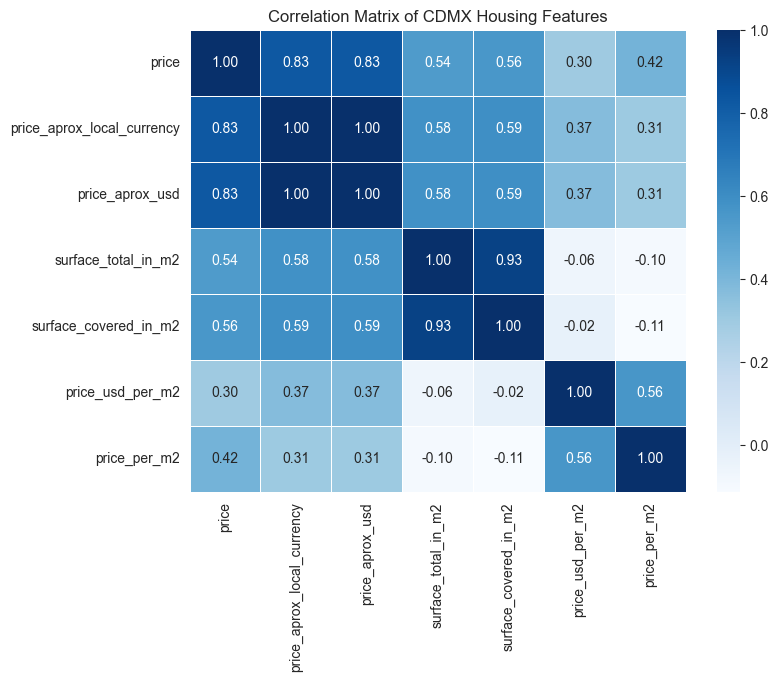

In [24]:
correlation_matrix =df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of CDMX Housing Features')
plt.show()

## **extract KPIs**

In [25]:
total_properties = len(df)
avg_price_usd = df['price_aprox_usd'].mean()
avg_price_m2_usd = df['price_usd_per_m2'].mean()

print(f"Total Properties: {total_properties:,.0f}")
print(f"Average Property Price: ${avg_price_usd:,.2f}")
print(f"Average Price per m²: ${avg_price_m2_usd:,.2f}")

Total Properties: 14,193
Average Property Price: $182,501.55
Average Price per m²: $1,349.20


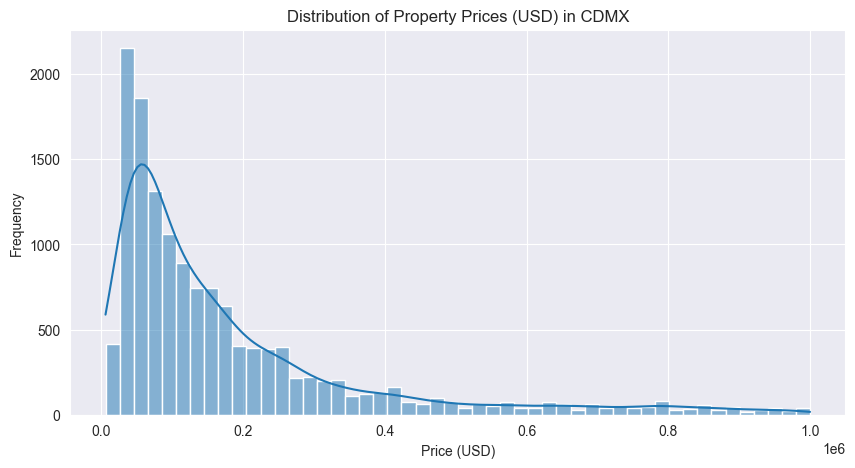

In [26]:
# Plot the distribution of property prices
plt.figure(figsize=(10, 5))
sns.histplot(df['price_aprox_usd'], bins=50, kde=True)
plt.title('Distribution of Property Prices (USD) in CDMX')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

## **Property Type Insights**

In [27]:
# Aggregate data by property type
type_insights = df.groupby('property_type').agg(
    property_count=('property_type', 'count'),
    avg_price_usd=('price_aprox_usd', 'mean'),
    avg_price_per_m2=('price_usd_per_m2', 'mean')
).round(2).sort_values(by='avg_price_usd', ascending=False)
display(type_insights)



,property_count,avg_price_usd,avg_price_per_m2
property_type,,,
PH,10,431198.36,1859.31
house,4034,243917.32,1159.13
store,135,200710.75,1840.39
apartment,10014,157267.24,1418.64


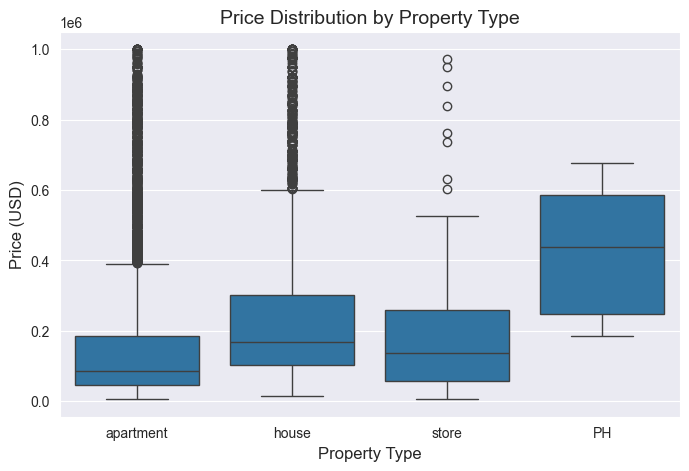

In [28]:
# Plot price distribution by property type to spot outliers
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='property_type', y='price_aprox_usd')
plt.title('Price Distribution by Property Type', fontsize=14)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.show()

## ****Top Places Analysis****

In [29]:
# Extract the most expensive places by price
borough_prices = df.groupby('places')['price_aprox_usd'].mean().round(2).sort_values(ascending=True)
borough_prices

places
Tlahuac                57900.95
Iztapalapa             71240.98
VenustianoCarranza     72585.54
Iztacalco              73316.91
MilpaAlta              85635.80
Azcapotzalco           86997.02
GustavoAMadero        108969.00
Cuauhtemoc            139930.29
Xochimilco            158921.75
Coyoacan              168595.74
BenitoJuarez          170916.80
AlvaroObregon         210149.38
Tlalpan               224008.72
MagdalenaContreras    286713.35
MiguelHidalgo         342402.90
Cuajimalpa            437940.60
Name: price_aprox_usd, dtype: float64

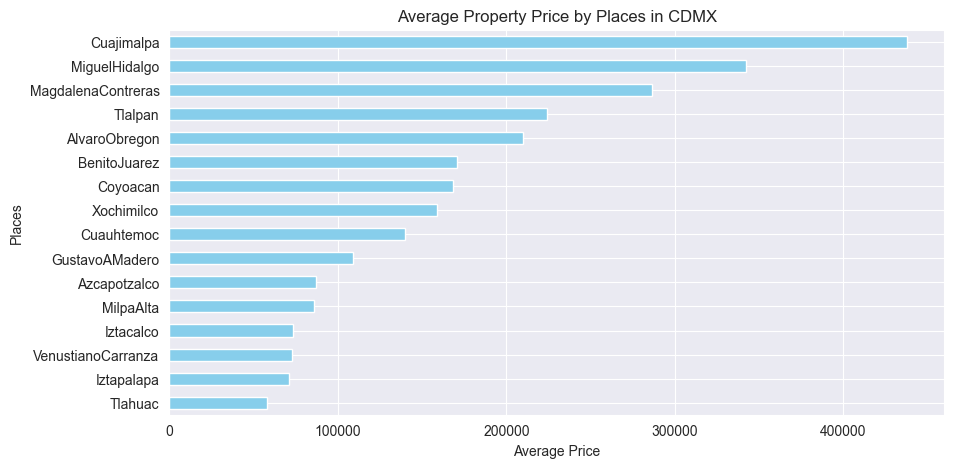

In [30]:
plt.figure(figsize=(10, 5))
borough_prices.plot(kind='barh', color='skyblue')
plt.title('Average Property Price by Places in CDMX')
plt.xlabel('Average Price')
plt.ylabel('Places')
plt.show()

In [31]:
# Extract the top 10 most expensive places by price per square meter
top_10_places = df.groupby('places')['price_usd_per_m2'].mean().sort_values(ascending=False).head(10)
top_10_places.round(2)

places
MiguelHidalgo         2023.73
Cuajimalpa            1955.47
BenitoJuarez          1597.88
AlvaroObregon         1409.01
Cuauhtemoc            1404.60
MagdalenaContreras    1296.41
Coyoacan              1232.68
Tlalpan               1140.38
Azcapotzalco          1117.95
GustavoAMadero         872.12
Name: price_usd_per_m2, dtype: float64

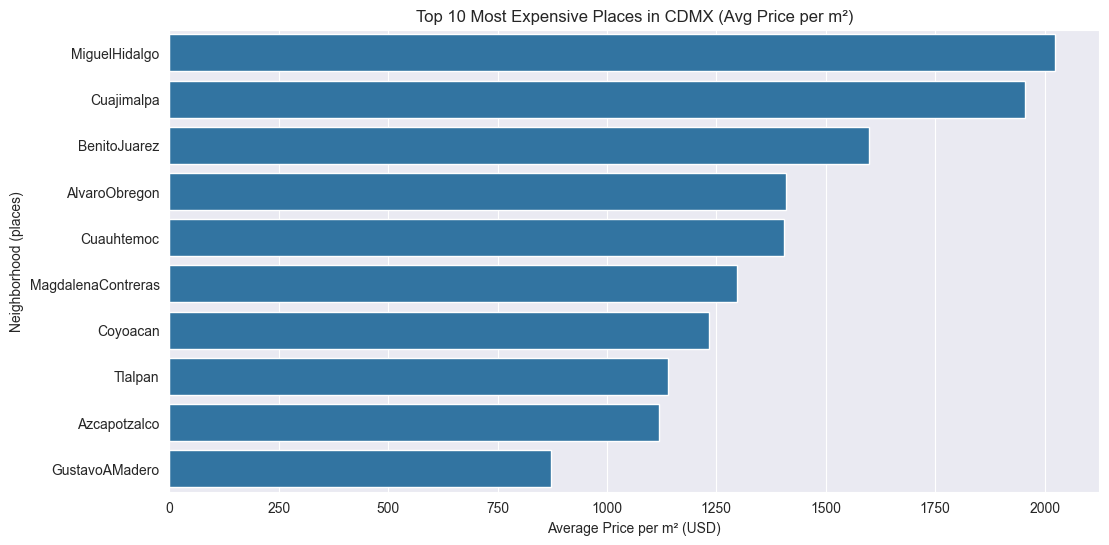

In [32]:
# Visualize the top 10 places using a bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_places.values, y=top_10_places.index)
plt.title('Top 10 Most Expensive Places in CDMX (Avg Price per m²)')
plt.xlabel('Average Price per m² (USD)')
plt.ylabel('Neighborhood (places)')
plt.show()

**Surface Area vs. Price Correlation**

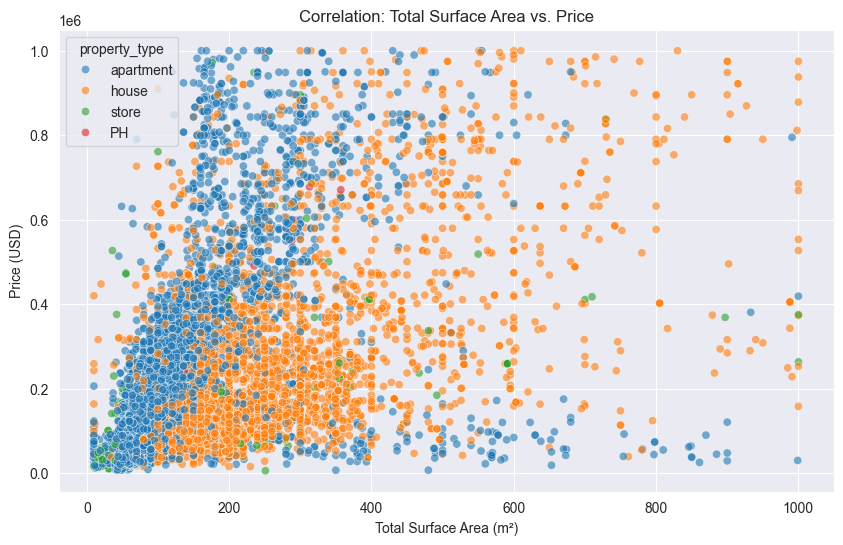

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='surface_total_in_m2', y='price_aprox_usd', hue='property_type', alpha=0.6)
plt.title('Correlation: Total Surface Area vs. Price', )
plt.xlabel('Total Surface Area (m²)')
plt.ylabel('Price (USD)')
plt.show()

**Create a new column classifying the property: Does it have an outdoor space or not?**

In [34]:
df["has_garden"]=df["surface_total_in_m2"]-df["surface_covered_in_m2"]
df["has_garden"]=df["has_garden"].apply(lambda x: "Yes" if x > 0 else "No")
df["has_garden"].head()

0    No
1    No
2    No
3    No
4    No
Name: has_garden, dtype: object

In [35]:
garden_prices = df.groupby('has_garden')['price_aprox_usd'].mean().round(2)
garden_prices

has_garden
No     175930.30
Yes    370639.68
Name: price_aprox_usd, dtype: float64

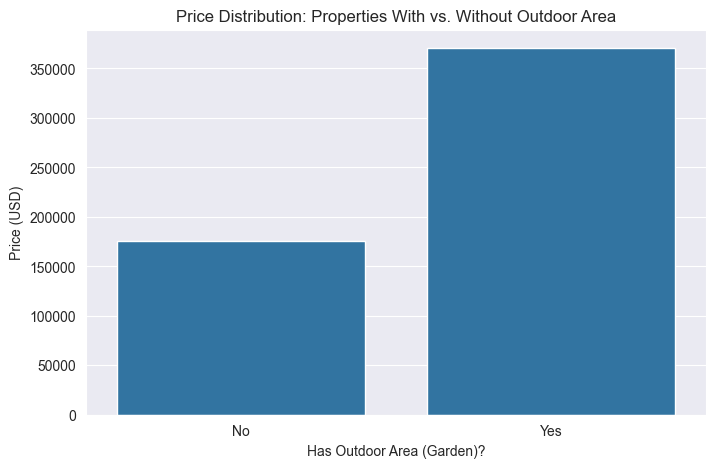

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(x=garden_prices.index, y=garden_prices.values)
plt.title('Price Distribution: Properties With vs. Without Outdoor Area')
plt.xlabel('Has Outdoor Area (Garden)?')
plt.ylabel('Price (USD)')
plt.show()

In [37]:
df.drop(columns=['price_aprox_local_currency','price',"price_per_m2","surface_covered_in_m2"], inplace=True)

In [38]:
df.to_csv(r'D:\SIC_P1_G16\dataset\housing_data_CDMX_cleaned.csv', index=False)